In [1]:
# LVDT_simulation/notebook/linear_fit_test.ipynb
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from core import data_handler

#### prototype demo

In [3]:
filename = "../simulation/data/demo/lvdt_result.h5"
# filename = "../simulation/data/prototype_2layers/lvdt_alucoil_10mm_0p1mm.h5"

data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=True)
curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

position = volt_data['position']
position_2d= position.reshape(-1, 1)
pickup_voltage = volt_data['Middle_Coil']['voltage_abs']
excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

norm_voltage_volt = pickup_voltage / excitation_voltage
norm_voltage_curr = pickup_voltage / excitation_current 

data_handler.non_linear_index(position, norm_voltage_curr)

3.943543633544643

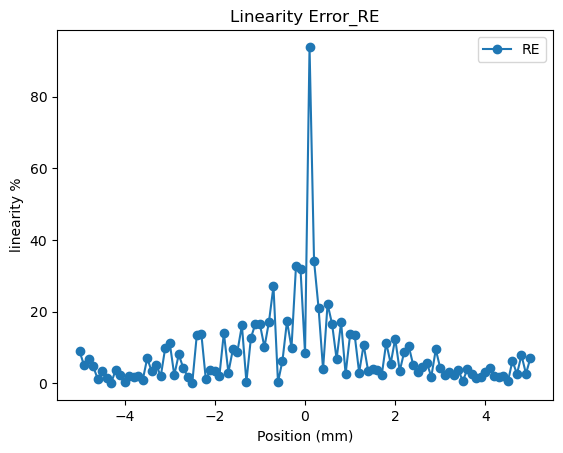

In [3]:
fit_params_RE = data_handler.linear_analysis_RE(position, norm_voltage_curr)
# fit_params_NN = data_handler.linear_analysis_NE(position, norm_voltage_curr)
fit_params_FS = data_handler.linear_analysis_FS(position, norm_voltage_curr)


plt.plot(position, fit_params_RE['error'], marker = 'o', label = 'RE')
# plt.plot(position, fit_params_NN['error'], marker = 'o', label = 'NE')
# plt.plot(position, fit_params_FS['error'], marker = 'o', label = 'FS')
plt.legend()
plt.title('Linearity Error_RE')
plt.xlabel('Position (mm)')
plt.ylabel('linearity %')
# plt.savefig('linearity_error_RE.pdf')
plt.show()

# plt.plot(position, norm_voltage_curr, marker = 'o', label = 'Measured')
# plt.plot(position, fit_params_FS['predict'], label = 'full scale fit')


#### typeA 

In [4]:
filename = "../simulation/data/typeA/lvdt_result.h5"

data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=False)
curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

position = volt_data['position']
position_2d= position.reshape(-1, 1)
pickup_voltage_1= (volt_data['Lower_OutCoil']['voltage_abs'])
pickup_voltage_2= (volt_data['Upper_OutCoil']['voltage_abs'])
pickup_voltage = -(pickup_voltage_1- pickup_voltage_2)
excitation_voltage= np.mean(abs(volt_data['Inn_Coil']['voltage_abs']))
excitation_current = np.mean(curr_data['Inn_Coil']['current_abs'])
norm_voltage_volt = pickup_voltage / excitation_voltage
norm_voltage_curr = pickup_voltage / excitation_current

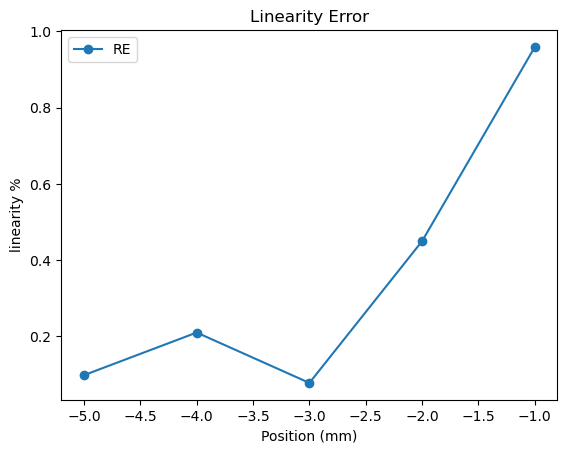

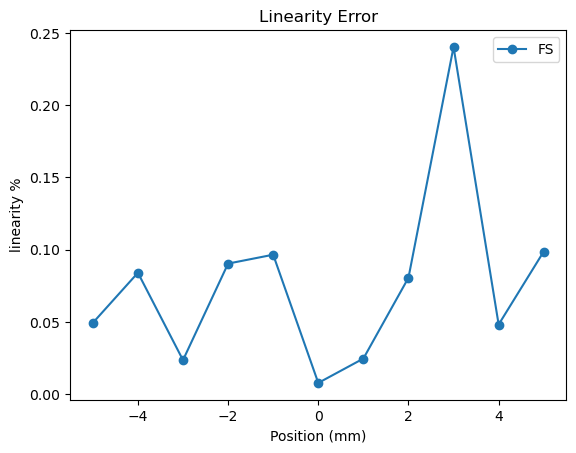

In [6]:
fit_params_RE = data_handler.linear_analysis_RE(position, norm_voltage_curr)
fit_params_FS = data_handler.linear_analysis_FS(position, norm_voltage_curr)


plt.plot(position[:5], fit_params_RE['error'][:5], marker = 'o', label = 'RE')
plt.legend()
plt.title('Linearity Error')
plt.xlabel('Position (mm)')
plt.ylabel('linearity %')
plt.show()
plt.plot(position, fit_params_FS['error'], marker = 'o', label = 'FS')
plt.legend()
plt.title('Linearity Error')
plt.xlabel('Position (mm)')
plt.ylabel('linearity %')
plt.show()